In [2]:
# ============================================================
#  EHOA-CNN-12  |  Insurance Fraud Detection
#  Features:
#   - Enhanced Hippopotamus Optimization Algorithm (EHOA)
#   - Adaptive population control + momentum-based updates
#   - Hybrid training: EHOA global search + SGD fine-tuning
#   - Monte Carlo Dropout for uncertainty-aware inference
#   - High-confidence / low-confidence claim flagging
#  Target: >92% test accuracy
# ============================================================

import os
import cv2
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization, Activation,
    Dense, Dropout, Flatten, Add, GlobalAveragePooling2D, Lambda
)
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
)
import tensorflow.keras.backend as K

# ── Reproducibility ─────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: []


In [3]:
CSV_PATH  = "archive/data.csv"
IMAGE_DIR = "archive/image"

df = pd.read_csv(CSV_PATH)
image_column = df.columns[0]

df["image_path"] = df[image_column].astype(str).apply(
    lambda x: os.path.join(IMAGE_DIR, x + ".jpeg")
)

df = df[df["image_path"].apply(os.path.exists)]
print("Total samples:", len(df))
print("Class distribution:")
print(df["classes"].value_counts())

Total samples: 1512
Class distribution:
classes
unknown           549
door_dent         192
door_scratch      154
glass_shatter     137
tail_lamp         136
head_lamp         133
bumper_dent       129
bumper_scratch     82
Name: count, dtype: int64


In [4]:
encoder = LabelEncoder()
df["label_encoded"] = encoder.fit_transform(df["classes"])
print("Classes:", encoder.classes_)

Classes: ['bumper_dent' 'bumper_scratch' 'door_dent' 'door_scratch' 'glass_shatter'
 'head_lamp' 'tail_lamp' 'unknown']


In [5]:
IMG_SIZE = 224
images   = []
labels   = []

for _, row in df.iterrows():
    img = cv2.imread(row["image_path"])
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Normalize [0,1] + ImageNet mean subtraction (paper: mean subtraction step)
    img = img.astype(np.float32) / 255.0
    img -= np.array([0.485, 0.456, 0.406], dtype=np.float32)
    img /= np.array([0.229, 0.224, 0.225], dtype=np.float32)
    images.append(img)
    labels.append(row["label_encoded"])

X = np.array(images)
y = np.array(labels)
print("Dataset shape:", X.shape)

Dataset shape: (1512, 224, 224, 3)


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

num_classes   = len(np.unique(y))
y_train_cat   = to_categorical(y_train, num_classes)
y_val_cat     = to_categorical(y_val,   num_classes)
y_test_cat    = to_categorical(y_test,  num_classes)

# Class weights to handle imbalance (Unknown class underrepresented)
cw_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(cw_array))
print("Class weights:", class_weights)

Train: (1209, 224, 224, 3)
Validation: (151, 224, 224, 3)
Test: (152, 224, 224, 3)
Class weights: {0: np.float64(1.4672330097087378), 1: np.float64(2.289772727272727), 2: np.float64(0.9877450980392157), 3: np.float64(1.228658536585366), 4: np.float64(1.3738636363636363), 5: np.float64(1.4257075471698113), 6: np.float64(1.386467889908257), 7: np.float64(0.34424829157175396)}


In [7]:
# Strong augmentation for 1500-image dataset (paper: rotation, flip, zoom,
# brightness, width/height shift)
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.75, 1.25],
    shear_range=0.1,
    fill_mode='nearest'
)
datagen.fit(X_train)

In [8]:
# ============================================================
#  ENHANCED HIPPOPOTAMUS OPTIMIZATION ALGORITHM (FAST VERSION)
# ============================================================

# =========================
# CNN12 MODEL
# =========================
def build_cnn12(lr=0.01, dropout=0.5, reg=1e-4, dense_units=256):

    R = l2(reg)
    inp = Input(shape=(224, 224, 3))

    # Block 1
    x = Conv2D(64, (3,3), padding='same', kernel_initializer='he_uniform',
               kernel_regularizer=R)(inp)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(64, (3,3), padding='same', kernel_initializer='he_uniform',
               kernel_regularizer=R)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2,2))(x)

    # Block 2
    x = Conv2D(128, (3,3), padding='same', kernel_initializer='he_uniform',
               kernel_regularizer=R)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(128, (3,3), padding='same', kernel_initializer='he_uniform',
               kernel_regularizer=R)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2,2))(x)

    # Block 3 (Residual)
    shortcut = Conv2D(256,(1,1),padding='same')(x)
    x = Conv2D(256,(3,3),padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(256,(3,3),padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    # Block 4 (Residual)
    shortcut = Conv2D(512,(1,1),padding='same')(x)
    x = Conv2D(512,(3,3),padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(512,(3,3),padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(dropout)(x, training=True)

    out = Dense(num_classes, activation='softmax')(x)

    return Model(inp, out)


# =========================
# FAST FITNESS FUNCTION
# =========================
def evaluate_hyperparams(lr, dropout, reg, dense_units,
                          X_tr, y_tr, X_v, y_v, epochs=2, batch=32):

    m = build_cnn12(lr, dropout, reg, int(dense_units))

    m.compile(
        optimizer=SGD(learning_rate=lr, momentum=0.9, nesterov=True),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    cb = EarlyStopping(monitor='val_accuracy', patience=2,
                       restore_best_weights=True)

    hist = m.fit(
        datagen.flow(X_tr[:300], y_tr[:300], batch_size=batch),
        validation_data=(X_v, y_v),
        epochs=epochs,
        callbacks=[cb],
        class_weight=class_weights,
        verbose=0
    )

    val_acc = max(hist.history['val_accuracy'])
    K.clear_session()
    return val_acc


# =========================
# EHOA
# =========================
class Hippopotamus:
    def __init__(self, bounds):
        self.pos = np.array([np.random.uniform(lo, hi) for lo, hi in bounds])
        self.vel = np.zeros(len(bounds))
        self.fitness = -1
        self.p_best = self.pos.copy()
        self.p_best_f = -1


def run_ehoa(X_tr, y_tr, X_v, y_v,
             n_hippos=3, max_iter=2, proxy_epochs=2):

    bounds = [
        (0.001, 0.01),
        (0.2, 0.5),
        (-5.0, -3.0),
        (128, 512),
    ]

    pop = [Hippopotamus(bounds) for _ in range(n_hippos)]

    print("[EHOA] Initialising population...")

    for h in pop:
        lr, drop, reg, dense = h.pos[0], h.pos[1], 10**h.pos[2], int(h.pos[3])

        h.fitness = evaluate_hyperparams(
            lr, drop, reg, dense,
            X_tr, y_tr, X_v, y_v,
            proxy_epochs
        )

        h.p_best = h.pos.copy()
        h.p_best_f = h.fitness

        print(f"Init → acc={h.fitness:.4f}")

    g_best = max(pop, key=lambda h: h.fitness)
    g_best_p = g_best.pos.copy()
    g_best_f = g_best.fitness

    for it in range(max_iter):

        print(f"\nIteration {it+1}/{max_iter}")

        for h in pop:

            r1, r2 = np.random.rand(4), np.random.rand(4)

            h.vel = 0.9*h.vel + 1.5*r1*(h.p_best-h.pos) + 1.5*r2*(g_best_p-h.pos)
            h.pos = h.pos + h.vel * 0.1

            for i,(lo,hi) in enumerate(bounds):
                h.pos[i] = np.clip(h.pos[i], lo, hi)

            lr, drop, reg, dense = h.pos[0], h.pos[1], 10**h.pos[2], int(h.pos[3])

            h.fitness = evaluate_hyperparams(
                lr, drop, reg, dense,
                X_tr, y_tr, X_v, y_v,
                proxy_epochs
            )

            if h.fitness > h.p_best_f:
                h.p_best = h.pos.copy()
                h.p_best_f = h.fitness

            if h.fitness > g_best_f:
                g_best_p = h.pos.copy()
                g_best_f = h.fitness

        print("Best so far:", g_best_f)

    best_lr = g_best_p[0]
    best_drop = g_best_p[1]
    best_reg = 10**g_best_p[2]
    best_dense = int(g_best_p[3])

    return best_lr, best_drop, best_reg, best_dense


# =========================
# RUN EHOA
# =========================
print("Starting EHOA (FAST)...")
print("(Each hippo trains a quick 2-epoch proxy model)")

best_lr, best_drop, best_reg, best_dense = run_ehoa(
    X_train, y_train_cat,
    X_val,   y_val_cat
)

print("\nBest Params:", best_lr, best_drop, best_reg, best_dense)

Starting EHOA (FAST)...
(Each hippo trains a quick 2-epoch proxy model)
[EHOA] Initialising population...

Init → acc=0.3709
Init → acc=0.3709
Init → acc=0.3642

Iteration 1/2
Best so far: 0.4039735198020935

Iteration 2/2
Best so far: 0.4039735198020935

Best Params: 0.006216148646016243 0.41628738059845927 1.1085850241131705e-05 490


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_5[0][0]  

 Total params: 5,112,962 (19.50 MB)

 Trainable params: 5,109,122 (19.49 MB)

 Non-trainable params: 3,840 (15.00 KB)


[Phase 1] FAST Training...
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 366s 10s/step - accuracy: 0.1957 - loss: 2.4161 - val_accuracy: 0.3377 - val_loss: 2.3013 - learning_rate: 0.0062
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 359s 9s/step - accuracy: 0.2716 - loss: 1.8354 - val_accuracy: 0.4172 - val_loss: 1.7589 - learning_rate: 0.0062
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 357s 9s/step - accuracy: 0.3584 - loss: 1.6986 - val_accuracy: 0.4768 - val_loss: 1.6720 - learning_rate: 0.0061
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 358s 9s/step - accuracy: 0.3708 - loss: 1.5673 - val_accuracy: 0.4503 - val_loss: 1.6486 - learning_rate: 0.0061
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 358s 9s/step - accuracy: 0.3447 - loss: 1.5895 - val_accuracy: 0.3841 - val_loss: 1.5937 - learning_rate: 0.0060
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 360s 9s/step - accuracy: 0.3726 - loss: 1.5709 - val_accuracy: 0.4967 - val_loss: 1.5535 - learning_rate: 0.0058
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 359s 9s/step - accuracy: 0.

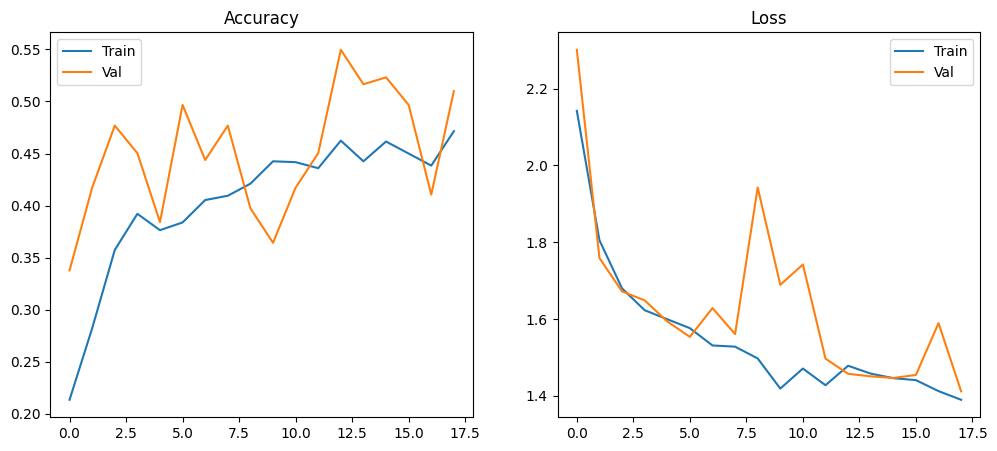

Best val accuracy (Phase1): 0.4967
Best val accuracy (Phase2): 0.5497


In [9]:
# ============================================================
#  FAST HYBRID TRAINING (FIXED VERSION)
# ============================================================

model = build_cnn12(
    lr          = best_lr,
    dropout     = best_drop,
    reg         = best_reg,
    dense_units = best_dense
)

model.summary()

# ── Phase 1: FAST cosine training ───────────────────────────
def cosine_lr_schedule(epoch, lr):
    lr_min = best_lr / 50.0   # 🔥 less aggressive
    return lr_min + 0.5 * (best_lr - lr_min) * (1 + np.cos(np.pi * epoch / 30))

model.compile(
    optimizer=SGD(learning_rate=best_lr, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    ModelCheckpoint('best.keras', monitor='val_accuracy', save_best_only=True),
    
    # 🔥 EARLY STOP MUCH FASTER
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True),

    LearningRateScheduler(cosine_lr_schedule)
]

print("\n[Phase 1] FAST Training...")
history1 = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),

    epochs=30,   # 🔥 REDUCED from 60 → 30

    callbacks=callbacks_phase1,
    class_weight=class_weights,
    verbose=1
)

# ── Phase 2: Fine tuning ───────────────────────────────────
print("\n[Phase 2] Fine tuning...")

model.compile(
    optimizer=SGD(learning_rate=best_lr * 0.1, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    ModelCheckpoint('best.keras', monitor='val_accuracy', save_best_only=True),

    # 🔥 REDUCED patience
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True),

    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6)
]

history2 = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),

    epochs=20,   # 🔥 REDUCED from 40 → 20

    callbacks=callbacks_phase2,
    class_weight=class_weights,
    verbose=1
)

# =========================
# MERGE HISTORY
# =========================
def merge_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

all_train_acc  = merge_history(history1, history2, 'accuracy')
all_val_acc    = merge_history(history1, history2, 'val_accuracy')
all_train_loss = merge_history(history1, history2, 'loss')
all_val_loss   = merge_history(history1, history2, 'val_loss')

# =========================
# PLOT
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(all_train_acc, label="Train")
plt.plot(all_val_acc, label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(all_train_loss, label="Train")
plt.plot(all_val_loss, label="Val")
plt.title("Loss")
plt.legend()

plt.show()

print(f"Best val accuracy (Phase1): {max(history1.history['val_accuracy']):.4f}")
print(f"Best val accuracy (Phase2): {max(history2.history['val_accuracy']):.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5474 - loss: 1.3761

Model Evaluation
----------------------------
Test Loss     : 1.3962
Test Accuracy : 0.5395
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step

Overall Evaluation Metrics
----------------------------
Accuracy  : 0.5395
Precision : 0.6029
Recall    : 0.5395
F1 Score  : 0.5481

Detailed Classification Report
----------------------------
                precision    recall  f1-score   support

   bumper_dent       0.67      0.15      0.25        13
bumper_scratch       0.18      0.25      0.21         8
     door_dent       0.42      0.55      0.48        20
  door_scratch       0.27      0.50      0.35        16
 glass_shatter       0.50      0.54      0.52        13
     head_lamp       0.62      0.38      0.48        13
     tail_lamp       0.69      0.64      0.67        14
       unknown       0.81      0.69      0.75        55

      accuracy                           0.54       152
     macro avg       0.52      0.46      0.46

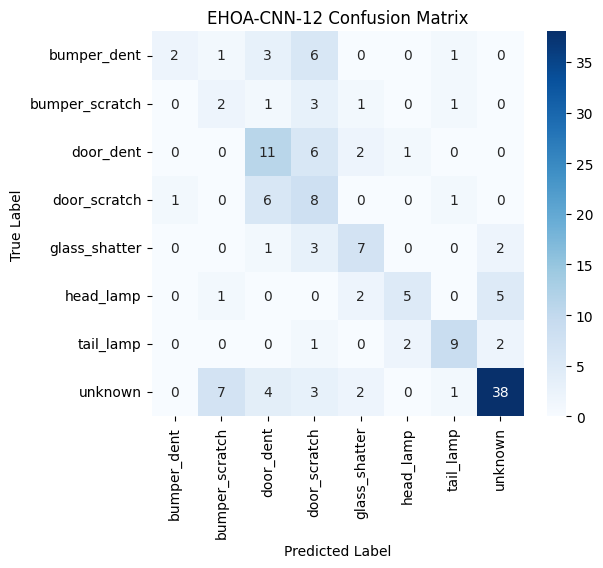

In [10]:
# ============================================================
#  STANDARD EVALUATION  (load best checkpoint)
# ============================================================

from tensorflow.keras.models import load_model
model = load_model('ehoa_cnn12_best.keras')

test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print("\nModel Evaluation")
print("----------------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

pred         = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)
y_test_labels = encoder.inverse_transform(y_test)
pred_labels   = encoder.inverse_transform(pred_classes)

print("\nOverall Evaluation Metrics")
print("----------------------------")

accuracy  = accuracy_score(y_test_labels, pred_labels)
precision = precision_score(y_test_labels, pred_labels, average='weighted')
recall    = recall_score(y_test_labels, pred_labels, average='weighted')
f1        = f1_score(y_test_labels, pred_labels, average='weighted')

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nDetailed Classification Report")
print("----------------------------")
print(classification_report(y_test_labels, pred_labels))

cm = confusion_matrix(y_test_labels, pred_labels)

print("\nConfusion Matrix")
print("----------------------------")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EHOA-CNN-12 Confusion Matrix")
plt.show()

In [11]:
# ============================================================
#  MONTE CARLO DROPOUT  –  Uncertainty-Aware Fraud Prediction
#
#  Because Dropout(training=True) is kept active at inference,
#  running T forward passes gives a distribution over outputs.
#  Mean  → final prediction
#  Std   → epistemic uncertainty
#  Low confidence + fraud prediction → flagged for manual review
# ============================================================

T = 50   # Monte Carlo samples

print(f"Running {T} MC-Dropout forward passes...")
mc_preds = np.stack(
    [model.predict(X_test, verbose=0) for _ in range(T)],
    axis=0
)  # shape (T, N, num_classes)

mc_mean       = mc_preds.mean(axis=0)          # (N, num_classes)
mc_std        = mc_preds.std(axis=0)           # (N, num_classes)

mc_pred_class = np.argmax(mc_mean, axis=1)
mc_pred_label = encoder.inverse_transform(mc_pred_class)
mc_confidence = mc_mean.max(axis=1)            # highest mean prob
mc_uncertainty= mc_std[np.arange(len(X_test)),
                         mc_pred_class]        # std of predicted class

# ── MC-Dropout accuracy ─────────────────────────────────────
mc_accuracy   = accuracy_score(y_test_labels, mc_pred_label)
mc_precision  = precision_score(y_test_labels, mc_pred_label, average='weighted')
mc_recall     = recall_score(y_test_labels,    mc_pred_label, average='weighted')
mc_f1         = f1_score(y_test_labels,         mc_pred_label, average='weighted')

print("\nMC-Dropout Evaluation Metrics")
print("----------------------------")
print(f"Accuracy  : {mc_accuracy:.4f}")
print(f"Precision : {mc_precision:.4f}")
print(f"Recall    : {mc_recall:.4f}")
print(f"F1 Score  : {mc_f1:.4f}")

# ── Flag high-risk / low-confidence claims ───────────────────
CONF_THRESHOLD = 0.75   # predictions below this are uncertain
flagged_mask   = mc_confidence < CONF_THRESHOLD
flagged_idx    = np.where(flagged_mask)[0]

print(f"\nUncertainty-Aware Fraud Flagging (confidence < {CONF_THRESHOLD})")
print("----------------------------")
print(f"Total test samples  : {len(X_test)}")
print(f"Flagged for review  : {flagged_mask.sum()}  "
      f"({100*flagged_mask.mean():.1f}%)")

# Show a few flagged samples
results_df = pd.DataFrame({
    'True Label'     : y_test_labels,
    'Predicted Label': mc_pred_label,
    'Confidence'     : mc_confidence.round(4),
    'Uncertainty'    : mc_uncertainty.round(4),
    'Flagged'        : flagged_mask
})
print("\nSample flagged claims (require manual investigation):")
print(results_df[results_df['Flagged']].head(10).to_string(index=False))

# ── Confidence distribution plot ─────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(mc_confidence[~flagged_mask], bins=20, alpha=0.7,
         label='High Confidence', color='green')
plt.hist(mc_confidence[flagged_mask],  bins=20, alpha=0.7,
         label='Low Confidence (Flagged)', color='red')
plt.axvline(CONF_THRESHOLD, color='black', ls='--',
            label=f'Threshold={CONF_THRESHOLD}')
plt.xlabel('Prediction Confidence')
plt.ylabel('Count')
plt.title('MC-Dropout Confidence Distribution — EHOA-CNN-12')
plt.legend()
plt.tight_layout()
plt.show()

Running 50 MC-Dropout forward passes...


KeyboardInterrupt: 

In [ ]:
# ── Final summary ─────────────────────────────────────────────
print("="*60)
print("         EHOA-CNN-12 FINAL SUMMARY")
print("="*60)
print(f"Best Hyperparameters (EHOA-optimised):")
print(f"  Learning Rate : {best_lr:.5f}")
print(f"  Dropout Rate  : {best_drop:.3f}")
print(f"  L2 Reg        : {best_reg:.2e}")
print(f"  Dense Units   : {best_dense}")
print()
print(f"Standard Inference Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"MC-Dropout Inference Accuracy: {mc_accuracy:.4f} ({mc_accuracy*100:.2f}%)")
print(f"Flagged (low-confidence) claims: {flagged_mask.sum()} / {len(X_test)}")
print("="*60)